# Energy - predictive equipment failure

Run the main pipeline first. This notebook explores training sensors and reviews held-out model/policy results separately. All records are synthetic. EDA is also executed in `src/energy_failure/reporting.py` by the main pipeline.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
metrics = json.loads((ROOT / "artifacts/metrics.json").read_text())
frame = pd.read_csv(ROOT / "data/processed/modeling_frame.csv", parse_dates=["date"])
cfg = metrics["config"]
train = frame[frame.date.between(cfg["train_start"], cfg["train_end"])].copy()
print(metrics["data"])
print("Training EDA rows:", len(train))


{'source': '100% synthetic; no AER or operator records', 'seed': 42, 'assets': 80, 'telemetry_start': '2024-01-01', 'telemetry_end': '2025-06-30', 'cadence': 'one daily snapshot per asset', 'expected_asset_days': 43760, 'raw_readings': 44011, 'failure_events': 236, 'currency': 'CAD', 'scenario': 'enriched-failure teaching sample; not Alberta failure-rate estimate'}
Training EDA rows: 22000


## Data quality and coverage

Missing values remain flagged after causal imputation. The raw daily schedule is complete, but communication outages remove all sensor values for several days.


In [2]:
display(pd.Series(metrics["quality"]["imputed_cells_by_sensor"], name="Imputed cells"))
display(train.groupby("asset_type")[["vibration_mm_s", "bearing_temperature_c", "pressure_bar", "rpm", "runtime_hours"]].describe().round(2))


vibration_mm_s           1321
bearing_temperature_c    1319
pressure_bar             1330
power_kw                 1342
load_pct                 1339
rpm                      1360
runtime_hours            1287
Name: Imputed cells, dtype: int64

vibration_mm_s                                           \
                       count  mean   std  min   25%   50%   75%   max   
asset_type                                                              
compressor            7425.0  3.47  0.97  0.0  2.95  3.32  3.82  9.84   
pipeline_pump         7150.0  2.50  1.08  0.0  1.88  2.24  2.81  7.40   
pumpjack              7425.0  2.90  1.00  0.0  2.34  2.71  3.24  8.89   

              bearing_temperature_c         ...      rpm           \
                              count   mean  ...      75%      max   
asset_type                                  ...                     
compressor                   7425.0  75.89  ...  1212.01  1298.36   
pipeline_pump                7150.0  64.02  ...  1765.71  1908.11   
pumpjack                     7425.0  57.31  ...    14.14    15.32   

              runtime_hours                                                   \
                      count      mean       std      min       25%       50%   
asset_type                                                                     
compressor           7425.0  38432.80  17024.52  8417.41  22303.53  42093.04   
pipeline_pump        7150.0  42511.04  19327.60  7662.26  22242.55  46177.71   
pumpjack             7425.0  37027.97  17627.57  8637.74  22636.80  34258.00   

                                   
                    75%       max  
asset_type                         
compressor     49634.88  68615.95  
pipeline_pump  60598.09  68540.18  
pumpjack       55453.77  66326.13  

[3 rows x 40 columns]

## Pre-failure degradation and sensor relationships

Centering within equipment type separates operating levels from degradation. These charts use only training rows. Event alignment is exploratory; days-to-failure is excluded from model features.


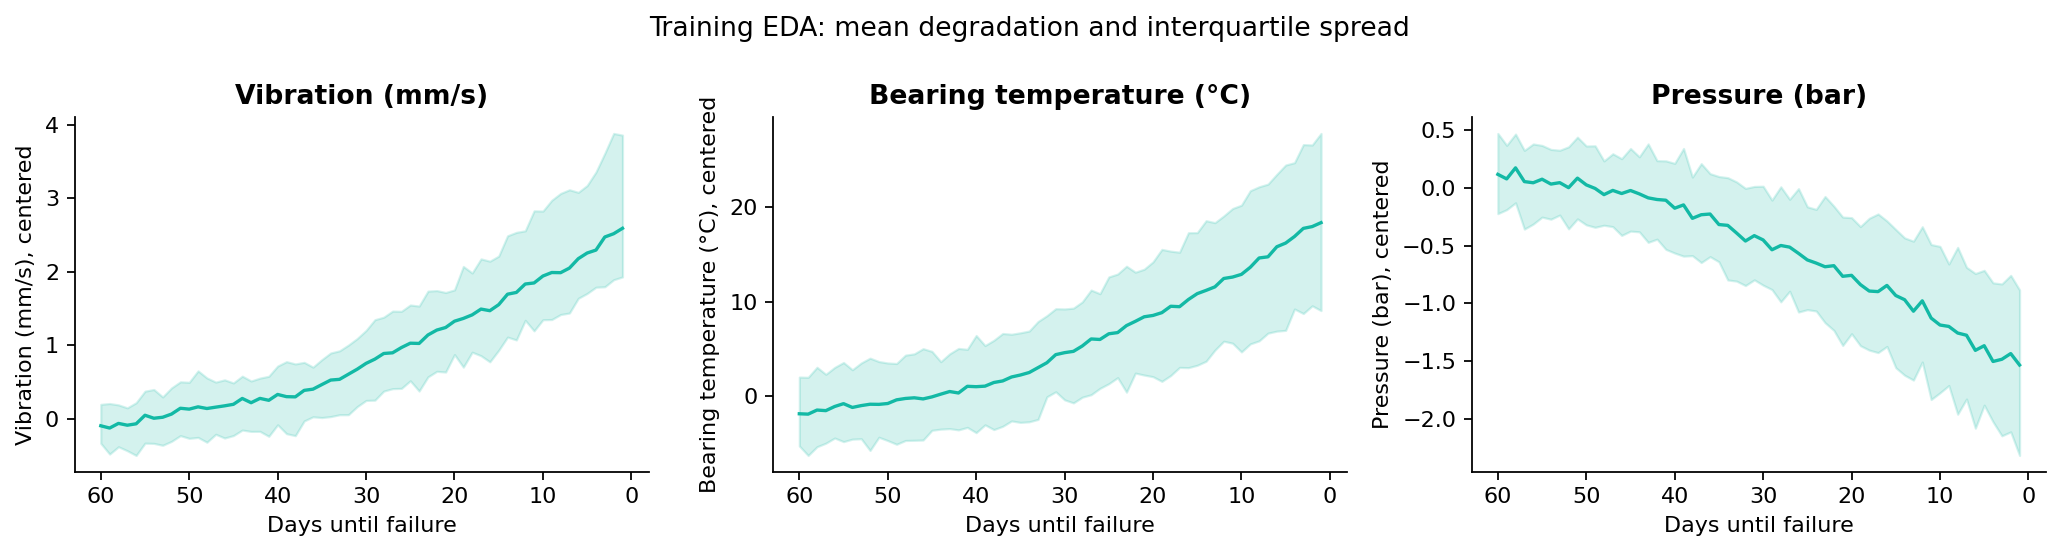

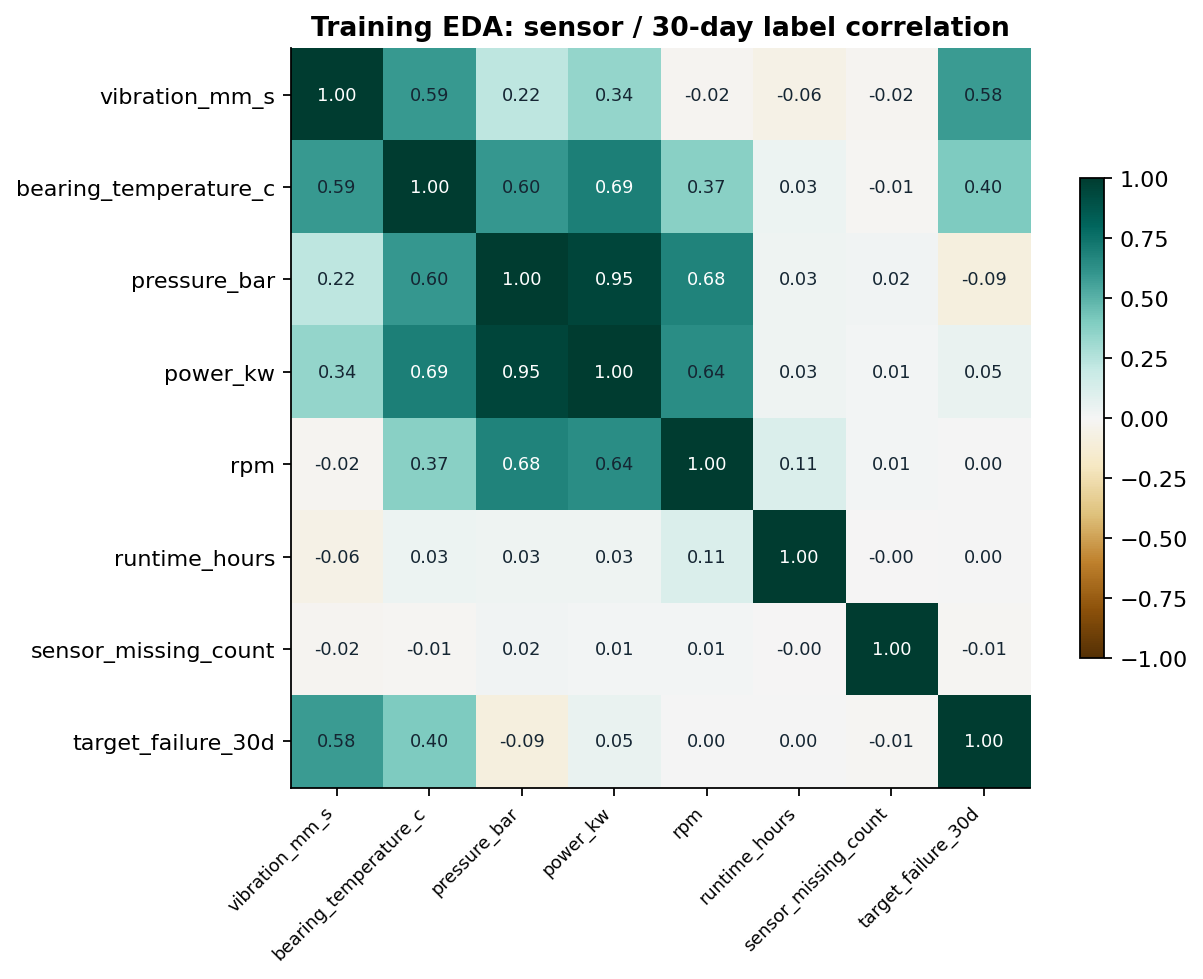

In [3]:
display(Image(filename=str(ROOT / "reports/figures/degradation_trends.png")))
display(Image(filename=str(ROOT / "reports/figures/sensor_correlation.png")))


## Validation decisions and held-out model evaluation

The threshold minimizes validation maintenance cost, not test precision/recall. The final 30 telemetry days are censored for classification. Asset-day metrics do not count independent failures.


,algorithm,average_precision,roc_auc,brier_score,precision,recall,positive_rate,rows,threshold,validation_policy_cost_cad
0,logistic_regression,0.868415,0.920348,0.047514,0.985052,0.546888,0.167361,7200,0.85,1823577.73
1,hist_gradient_boosting,0.902753,0.963641,0.048257,0.987879,0.541079,0.167361,7200,0.90,1815777.73


,algorithm,average_precision,roc_auc,brier_score,precision,recall,positive_rate,rows,threshold
0,logistic_regression,0.908961,0.959089,0.042544,0.963462,0.586651,0.175,4880,0.85
1,hist_gradient_boosting,0.930547,0.973581,0.035554,0.991228,0.661593,0.175,4880,0.90


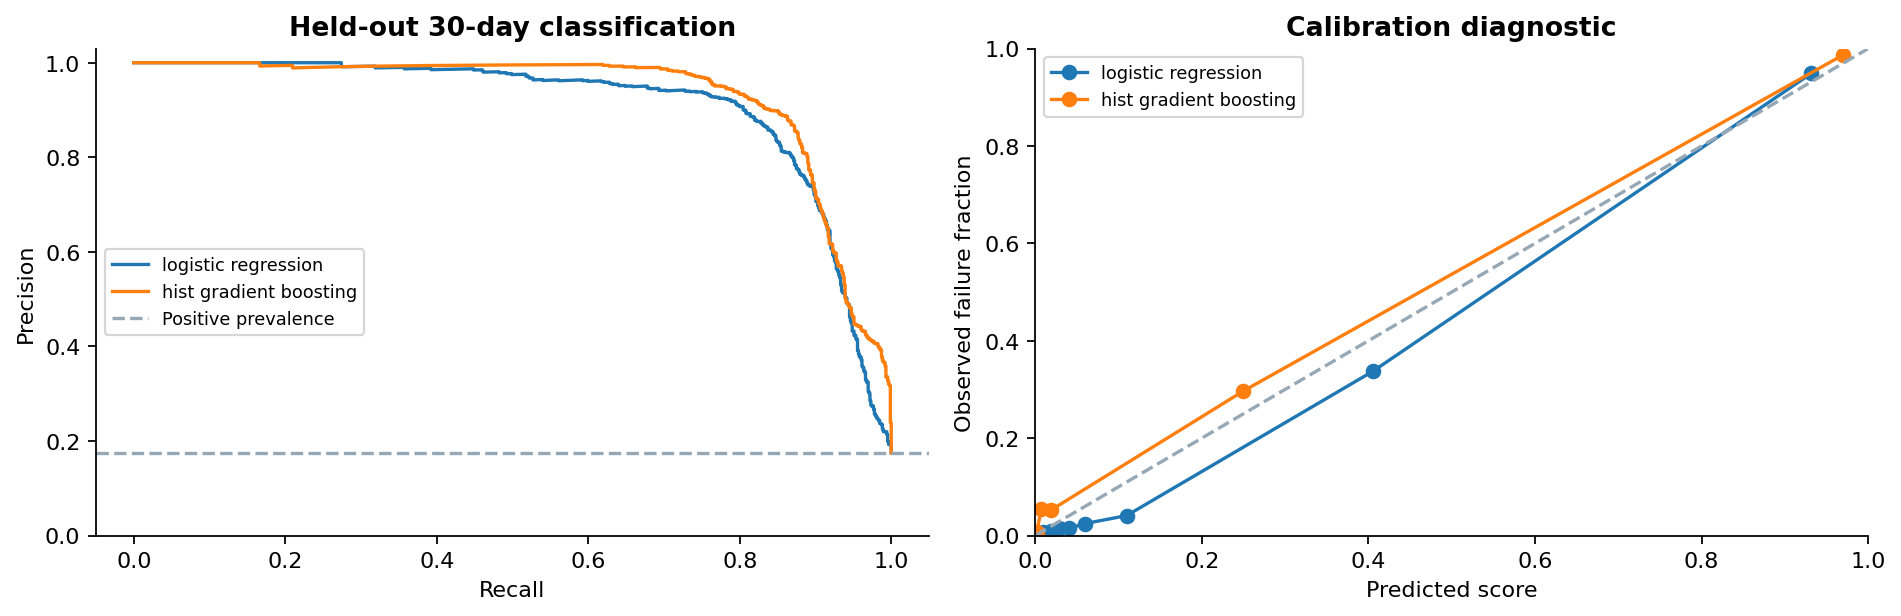

In [4]:
display(pd.read_csv(ROOT / "reports/validation_models.csv"))
display(pd.read_csv(ROOT / "reports/test_models.csv"))
display(Image(filename=str(ROOT / "reports/figures/model_tradeoffs.png")))


## Business baseline: the same failure history

Reactive maintenance has zero warning. Fixed 90-day visits catch only actionable faults at a successful service. Every in-period service is charged; pre-period scheduled service can carry protection into the test window. Predictive alerts must allow dispatch and respect cooldown.


policy,reactive,fixed_90_day,predictive
event_count,4.400000e+01,4.400000e+01,4.400000e+01
caught_failures,0.000000e+00,1.300000e+01,3.700000e+01
missed_failures,4.400000e+01,3.100000e+01,7.000000e+00
service_visits,0.000000e+00,8.100000e+01,5.100000e+01
carry_in_visits,0.000000e+00,2.500000e+01,0.000000e+00
unnecessary_services,0.000000e+00,6.800000e+01,1.000000e+01
unsuccessful_services,0.000000e+00,1.000000e+00,4.000000e+00
planned_downtime_hours,0.000000e+00,4.860000e+02,3.020000e+02
unplanned_downtime_hours,3.877000e+03,2.607100e+03,4.690000e+02
total_downtime_hours,3.877000e+03,3.093100e+03,7.710000e+02


,event_id,asset_id,event_date,caught,service_date,warning_days
44,E-AB-001-03,AB-001,2025-05-18,0,NaN,0
45,E-AB-004-03,AB-004,2025-05-28,0,NaN,0
46,E-AB-007-03,AB-007,2025-04-14,0,NaN,0
47,E-AB-008-03,AB-008,2025-04-11,0,NaN,0
48,E-AB-010-03,AB-010,2025-06-06,0,NaN,0
49,E-AB-011-03,AB-011,2025-06-23,1,2025-06-13,10
50,E-AB-012-04,AB-012,2025-05-19,0,NaN,0
51,E-AB-013-03,AB-013,2025-04-24,1,2025-04-08,16
52,E-AB-014-03,AB-014,2025-05-28,0,NaN,0
53,E-AB-016-03,AB-016,2025-05-22,0,NaN,0


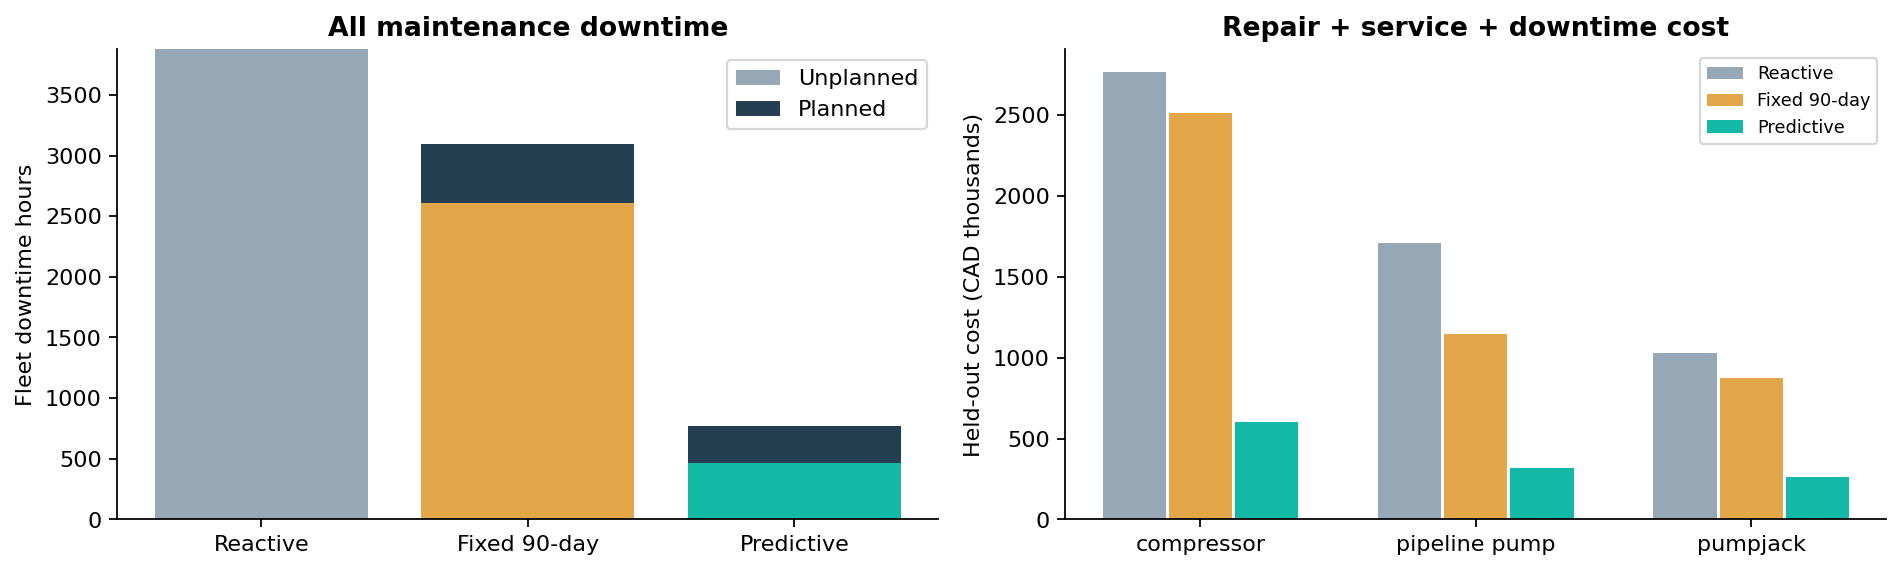

In [5]:
policies = pd.read_csv(ROOT / "data/processed/dashboard/policy_summary.csv")
display(policies.set_index("policy").T)
outcomes = pd.read_csv(ROOT / "data/processed/dashboard/event_outcomes.csv")
display(outcomes[outcomes.policy.eq("fixed_90_day")][["event_id", "asset_id", "event_date", "caught", "service_date", "warning_days"]].head(20))
display(Image(filename=str(ROOT / "reports/figures/policy_business_case.png")))


## Sensitivity and limitations

Annualization extrapolates 91 synthetic days. Failure rates and prices are illustrative; sensors are not regenerated after counterfactual interventions. Negative savings under a shorter actionable window must be retained. Read `docs/methodology.md` before interpreting results.


In [6]:
display(pd.read_csv(ROOT / "reports/sensitivity.csv"))
print(metrics["headline"])


,actionable_days,intervention_success,annualized_savings_cad,unplanned_downtime_reduction_pct,predictive_caught,fixed_caught
0,14,0.7,-8.844545e+05,-8.944799,7,9
1,14,0.9,4.064627e+05,0.070087,11,10
2,14,1.0,4.064627e+05,0.070087,11,10
3,21,0.7,2.873370e+06,13.366181,15,10
4,21,0.9,6.112825e+06,37.138932,23,11
5,21,1.0,7.116004e+06,42.942689,26,12
6,30,0.7,9.624723e+06,51.071151,27,12
7,30,0.9,1.342025e+07,82.010663,37,13
8,30,1.0,1.476683e+07,92.579009,41,14
9,45,0.7,8.556580e+06,47.629797,27,14


{'median_warning_days': 19.0, 'unplanned_downtime_reduction_pct': 82.01066318898394, 'annualized_net_savings_cad': 13420251.467554942, 'annualized_emergency_repair_savings_cad': 4931919.895961539}
